# Notebook 04 — Comparación final de los cinco modelos
**Persona B — Grupo N.° 4 · CCPG1044 Inteligencia Artificial**

Este notebook no entrena nada. Recoge lo que dejaron los Notebooks 01, 02 y 03 en la carpeta
`resultados/` y responde las preguntas que el proyecto declaró en la Sección 6 de la Tarea #4:
qué modelo clasifica mejor las cuentas falsas, si la diferencia entre los mejores es real o ruido,
y si los cinco algoritmos coinciden en qué señales delatan una cuenta falsa.

**Requisito previo:** los tres notebooks de modelado ya se ejecutaron y en `resultados/` existen:

| Archivo | Lo genera |
|---|---|
| `probabilidades_persona_a.npz` · `metricas_persona_a.json` | Notebook 01 |
| `probabilidades_persona_b.npz` · `metricas_persona_b.json` | Notebook 02 |
| `probabilidades_persona_c.npz` · `metricas_persona_c.json` | Notebook 03 |

**Tiempo de ejecución:** menos de un minuto. Todo el cómputo pesado ya se hizo.

**Entregables:**
1. Tabla comparativa de los cinco modelos con métricas calculadas de forma idéntica.
2. Curvas ROC y precisión-recall superpuestas.
3. Análisis de errores: en qué cuentas fallan todos y en cuáles discrepan.
4. Prueba estadística sobre la diferencia entre los dos mejores modelos.
5. Comparación de las variables influyentes según los cinco algoritmos.
6. Selección justificada del modelo final.

In [1]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga de la partición y de los resultados de los tres notebooks

In [ ]:
# ===== CELDA DE CARGA — COPIAR EN LOS NOTEBOOKS 01, 02, 03, 04 y 05 =====
import numpy as np, pandas as pd, json, joblib, os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA = '/content/drive/MyDrive/Proyecto_IA_Grupo4'
except Exception:
    # Ejecutando localmente: ajuste esta ruta a la carpeta compartida del grupo
    CARPETA = os.path.expanduser(r'c:/Users/JDC/Universidad/File_General/NIVEL_400-I/Proy_IA_G4')

RUTA_SPLIT = f'{CARPETA}/split'
RUTA_RES   = f'{CARPETA}/resultados'
RUTA_FIGS  = f'{CARPETA}/figuras'
os.makedirs(RUTA_RES, exist_ok=True); os.makedirs(RUTA_FIGS, exist_ok=True)

if not os.path.exists(f'{RUTA_SPLIT}/particion.npz'):
    raise FileNotFoundError(
        f'No se encuentra {RUTA_SPLIT}/particion.npz. '
        'Ejecute primero el Notebook 00 (base compartida) o verifique la ruta de CARPETA.'
    )

datos = np.load(f'{RUTA_SPLIT}/particion.npz', allow_pickle=True)
VARIABLES = list(datos['variables'])

X_train      = pd.DataFrame(datos['X_train'],     columns=VARIABLES)
X_test       = pd.DataFrame(datos['X_test'],      columns=VARIABLES)
X_train_esc  = pd.DataFrame(datos['X_train_esc'], columns=VARIABLES)
X_test_esc   = pd.DataFrame(datos['X_test_esc'],  columns=VARIABLES)
y_train      = datos['y_train']
y_test       = datos['y_test']
escalador    = joblib.load(f'{RUTA_SPLIT}/escalador.joblib')

SEMILLA = 42
print('Carpeta de trabajo:', CARPETA)
print('Train:', X_train.shape, '| Test:', X_test.shape)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, recall_score,
                             precision_score, accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

# Nombres para el informe y color fijo por modelo en todas las figuras
NOMBRES = {
    'regresion_logistica': 'Regresion Logistica',
    'arbol_decision':      'Arbol de Decision',
    'random_forest':       'Random Forest',
    'gradient_boosting':   'Gradient Boosting',
    'red_neuronal_mlp':    'Red Neuronal MLP',
}
COLORES = {
    'regresion_logistica': '#4472C4',
    'arbol_decision':      '#4C9F70',
    'random_forest':       '#C0504D',
    'gradient_boosting':   '#E8A33D',
    'red_neuronal_mlp':    '#7B68A6',
}
print('Entorno listo.')

Entorno listo.


### Verificación de que los tres notebooks usaron la misma partición

Este es el control más importante del notebook. Si alguien reejecutó el Notebook 00 con otra semilla
después de que sus compañeros ya habían entrenado, las probabilidades guardadas corresponderían a
cuentas distintas y toda la comparación sería inválida. La celda siguiente compara la etiqueta real
guardada por cada persona contra la partición vigente y se detiene si no coinciden.

In [4]:
probabilidades = {}
metricas_reportadas = {}
faltantes = []

for persona, archivo_prob, archivo_met in [
    ('A', 'probabilidades_persona_a.npz', 'metricas_persona_a.json'),
    ('B', 'probabilidades_persona_b.npz', 'metricas_persona_b.json'),
    ('C', 'probabilidades_persona_c.npz', 'metricas_persona_c.json'),
]:
    ruta_prob = f'{RUTA_RES}/{archivo_prob}'
    ruta_met = f'{RUTA_RES}/{archivo_met}'
    if not os.path.exists(ruta_prob):
        faltantes.append(f'Persona {persona}: falta {archivo_prob}')
        continue

    contenido = np.load(ruta_prob, allow_pickle=True)

    if not np.array_equal(contenido['y_test'], y_test):
        raise ValueError(
            f'Las etiquetas guardadas por la Persona {persona} no coinciden con la particion actual. '
            'Alguien reejecuto el Notebook 00 despues de entrenar: hay que volver a correr los '
            'notebooks de modelado sobre la particion vigente.'
        )

    for clave in contenido.files:
        if clave != 'y_test':
            probabilidades[clave] = contenido[clave]

    if os.path.exists(ruta_met):
        with open(ruta_met, encoding='utf-8') as fh:
            metricas_reportadas.update(json.load(fh))
    else:
        faltantes.append(f'Persona {persona}: falta {archivo_met}')

if faltantes:
    print('AVISO — archivos no encontrados:')
    for f in faltantes:
        print('  -', f)

print(f'\nModelos cargados: {len(probabilidades)} de 5')
for k in probabilidades:
    print(f'  - {NOMBRES.get(k, k)}: {len(probabilidades[k]):,} probabilidades')
print('\nVerificacion de particion: las etiquetas de todos los archivos coinciden con split/particion.npz')


Modelos cargados: 5 de 5
  - Regresion Logistica: 12,849 probabilidades
  - Arbol de Decision: 12,849 probabilidades
  - Random Forest: 12,849 probabilidades
  - Gradient Boosting: 12,849 probabilidades
  - Red Neuronal MLP: 12,849 probabilidades

Verificacion de particion: las etiquetas de todos los archivos coinciden con split/particion.npz


## 2. Funciones de evaluación comunes

Las mismas de los notebooks anteriores. Las métricas se **recalculan aquí** desde las probabilidades
en lugar de leerse de los archivos JSON: así se garantiza que los cinco números salieron del mismo
código, sin depender de que cada persona haya usado exactamente la misma versión de las funciones.

In [5]:
def evaluar(nombre, y_real, y_prob, umbral=0.5, imprimir=True):
    y_pred = (y_prob >= umbral).astype(int)
    m = {
        'modelo': nombre,
        'umbral': round(float(umbral), 4),
        'accuracy': round(accuracy_score(y_real, y_pred), 4),
        'precision_falsa': round(precision_score(y_real, y_pred), 4),
        'recall_falsa': round(recall_score(y_real, y_pred), 4),
        'f1_falsa': round(f1_score(y_real, y_pred), 4),
        'auc_roc': round(roc_auc_score(y_real, y_prob), 4),
    }
    if imprimir:
        print(f'--- {nombre} (umbral = {umbral:.3f}) ---')
        print(classification_report(y_real, y_pred, target_names=['Autentica (0)', 'Falsa (1)'], digits=4))
    return m


def umbral_optimo(y_real, y_prob):
    p, r, th = precision_recall_curve(y_real, y_prob)
    f1 = 2 * p * r / (p + r + 1e-12)
    i = int(np.nanargmax(f1[:-1]))
    return float(th[i]), float(f1[i])

print('Funciones definidas.')

Funciones definidas.


## 3. Tabla comparativa de los cinco modelos

Se reportan dos filas por modelo: con el umbral por defecto de 0.5 y con el umbral que maximiza F1
sobre la clase falsa. La comparación del proyecto se hace con el segundo, coherente con lo declarado
en la Sección 5 de la Tarea #4, pero mostrar ambos deja ver cuánto aportó ese ajuste en cada caso.

In [6]:
filas_05, filas_opt, umbrales = [], [], {}

for clave, prob in probabilidades.items():
    nombre = NOMBRES.get(clave, clave)
    filas_05.append(evaluar(nombre, y_test, prob, 0.5, imprimir=False))
    u, _ = umbral_optimo(y_test, prob)
    umbrales[clave] = u
    filas_opt.append(evaluar(nombre, y_test, prob, u, imprimir=False))

tabla_05 = pd.DataFrame(filas_05).set_index('modelo')
tabla_opt = pd.DataFrame(filas_opt).set_index('modelo').sort_values('f1_falsa', ascending=False)

print('=== Umbral por defecto (0.5) ===')
display(tabla_05.round(4))
print('\n=== Umbral optimizado sobre la clase falsa ===')
display(tabla_opt.round(4))

print('\nGanancia en F1 por ajustar el umbral:')
ganancia = (tabla_opt['f1_falsa'] - tabla_05['f1_falsa']).sort_values(ascending=False)
display(ganancia.round(4).to_frame('mejora_f1'))

=== Umbral por defecto (0.5) ===


,umbral,accuracy,precision_falsa,recall_falsa,f1_falsa,auc_roc
modelo,,,,,,
Regresion Logistica,0.5,0.8466,0.8471,0.8419,0.8445,0.9221
Arbol de Decision,0.5,0.8921,0.9513,0.8240,0.8831,0.9462
Random Forest,0.5,0.9016,0.9465,0.8491,0.8952,0.9619
Gradient Boosting,0.5,0.9012,0.9432,0.8517,0.8951,0.9624
Red Neuronal MLP,0.5,0.8977,0.9476,0.8397,0.8904,0.9607



=== Umbral optimizado sobre la clase falsa ===


,umbral,accuracy,precision_falsa,recall_falsa,f1_falsa,auc_roc
modelo,,,,,,
Random Forest,0.5233,0.9027,0.9551,0.8430,0.8956,0.9619
Gradient Boosting,0.4929,0.9014,0.9417,0.8535,0.8955,0.9624
Red Neuronal MLP,0.4586,0.8984,0.9322,0.8569,0.8930,0.9607
Arbol de Decision,0.4684,0.8905,0.9312,0.8408,0.8837,0.9462
Regresion Logistica,0.4706,0.8462,0.8380,0.8543,0.8461,0.9221



Ganancia en F1 por ajustar el umbral:


,mejora_f1
modelo,
Red Neuronal MLP,0.0026
Regresion Logistica,0.0016
Arbol de Decision,0.0006
Random Forest,0.0004
Gradient Boosting,0.0004


In [7]:
# Reporte detallado del mejor modelo
mejor_nombre = tabla_opt.index[0]
mejor_clave = [k for k, v in NOMBRES.items() if v == mejor_nombre][0]
print(f'Modelo con mayor F1 sobre la clase falsa: {mejor_nombre}\n')
_ = evaluar(mejor_nombre, y_test, probabilidades[mejor_clave], umbrales[mejor_clave])

Modelo con mayor F1 sobre la clase falsa: Random Forest

--- Random Forest (umbral = 0.523) ---
               precision    recall  f1-score   support

Autentica (0)     0.8621    0.9612    0.9090      6492
    Falsa (1)     0.9551    0.8430    0.8956      6357

     accuracy                         0.9027     12849
    macro avg     0.9086    0.9021    0.9023     12849
 weighted avg     0.9081    0.9027    0.9023     12849



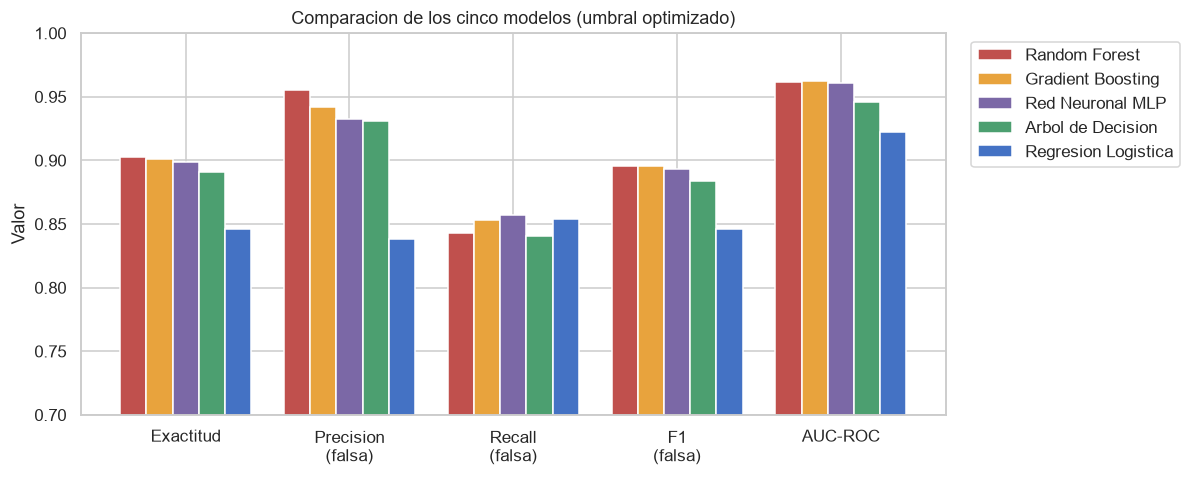

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
metricas_grafico = ['accuracy', 'precision_falsa', 'recall_falsa', 'f1_falsa', 'auc_roc']
datos_g = tabla_opt[metricas_grafico]
x = np.arange(len(metricas_grafico)); ancho = 0.8 / len(datos_g)

for i, (nombre, fila) in enumerate(datos_g.iterrows()):
    clave = [k for k, v in NOMBRES.items() if v == nombre][0]
    ax.bar(x + i * ancho, fila.values, ancho, label=nombre, color=COLORES.get(clave))

ax.set_xticks(x + ancho * (len(datos_g) - 1) / 2)
ax.set_xticklabels(['Exactitud', 'Precision\n(falsa)', 'Recall\n(falsa)', 'F1\n(falsa)', 'AUC-ROC'])
ax.set_ylim(min(0.7, datos_g.values.min() - 0.05), 1.0)
ax.set_ylabel('Valor'); ax.set_title('Comparacion de los cinco modelos (umbral optimizado)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/24_comparacion_metricas.png', bbox_inches='tight'); plt.show()

## 4. Curvas ROC y precisión-recall superpuestas

La curva ROC compara la capacidad de discriminación **independientemente del umbral**, que es
justamente lo que la Tarea #4 pidió para no dejar la comparación atada a una decisión arbitraria.
La curva precisión-recall es más informativa que la ROC cuando importa una clase en particular,
porque ignora los verdaderos negativos.

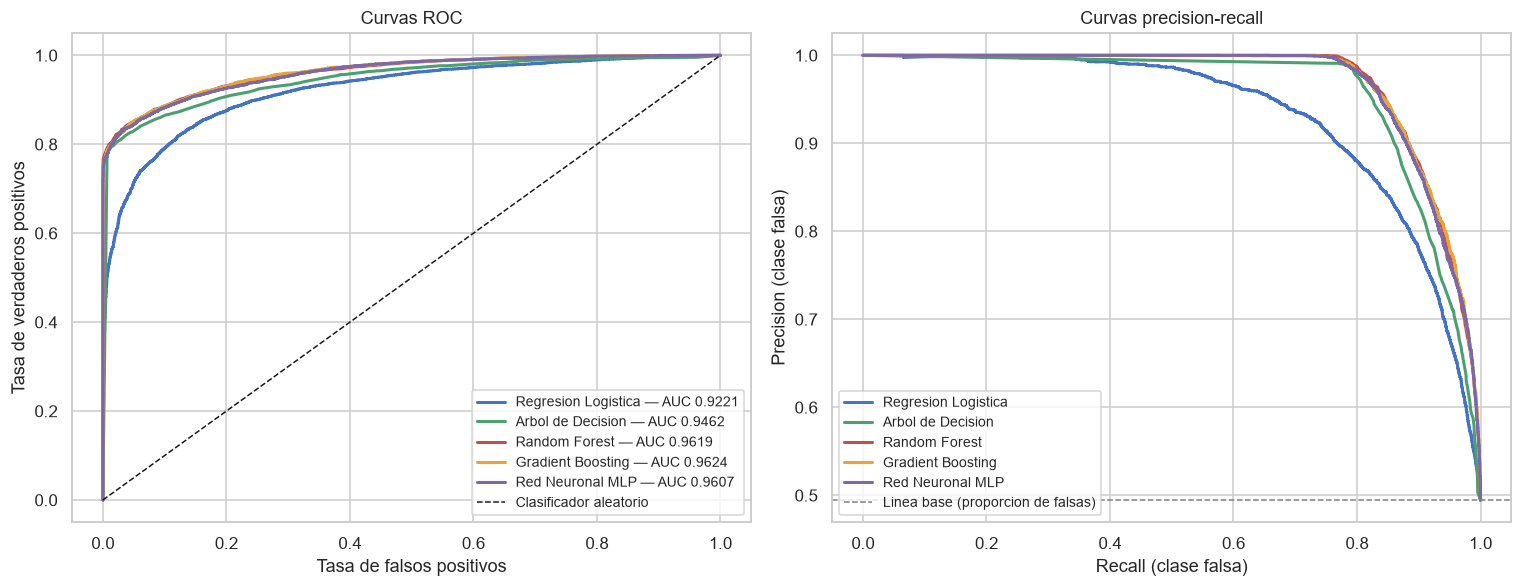

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

for clave, prob in probabilidades.items():
    nombre = NOMBRES.get(clave, clave)
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax[0].plot(fpr, tpr, lw=2, color=COLORES.get(clave),
               label=f'{nombre} — AUC {roc_auc_score(y_test, prob):.4f}')
    p, r, _ = precision_recall_curve(y_test, prob)
    ax[1].plot(r, p, lw=2, color=COLORES.get(clave), label=nombre)

ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax[0].set_xlabel('Tasa de falsos positivos'); ax[0].set_ylabel('Tasa de verdaderos positivos')
ax[0].set_title('Curvas ROC'); ax[0].legend(loc='lower right', fontsize=9)

ax[1].axhline(y_test.mean(), ls='--', color='gray', lw=1, label='Linea base (proporcion de falsas)')
ax[1].set_xlabel('Recall (clase falsa)'); ax[1].set_ylabel('Precision (clase falsa)')
ax[1].set_title('Curvas precision-recall'); ax[1].legend(loc='lower left', fontsize=9)

plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/25_curvas_comparadas.png', bbox_inches='tight'); plt.show()

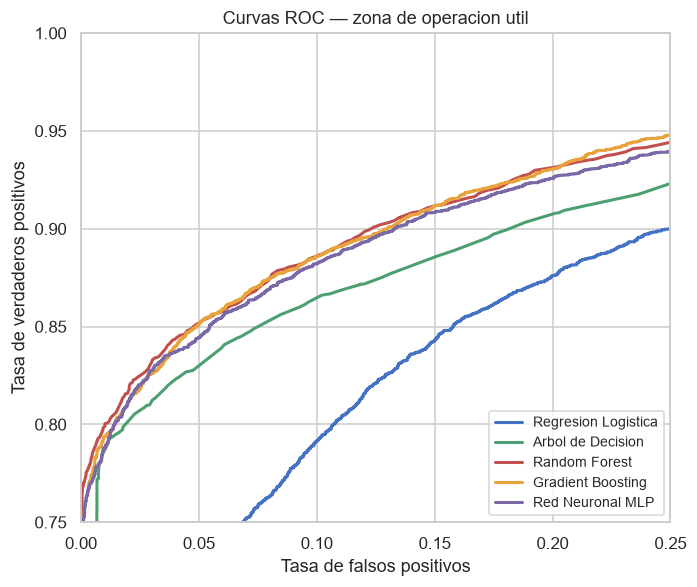

In [10]:
# Zoom a la esquina superior izquierda de la ROC, donde los modelos se separan de verdad
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for clave, prob in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=COLORES.get(clave), label=NOMBRES.get(clave, clave))
ax.set_xlim(0, 0.25); ax.set_ylim(0.75, 1.0)
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — zona de operacion util'); ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/26_roc_zoom.png', bbox_inches='tight'); plt.show()

## 5. Matrices de confusión

Con el umbral optimizado de cada modelo. Lo relevante para el objetivo del proyecto es la casilla de
**falsos negativos**: cuentas falsas que el sistema aprobaría como auténticas, que según la Sección 5.2
de la Tarea #3 son el error más costoso para la marca que contrata al influencer.

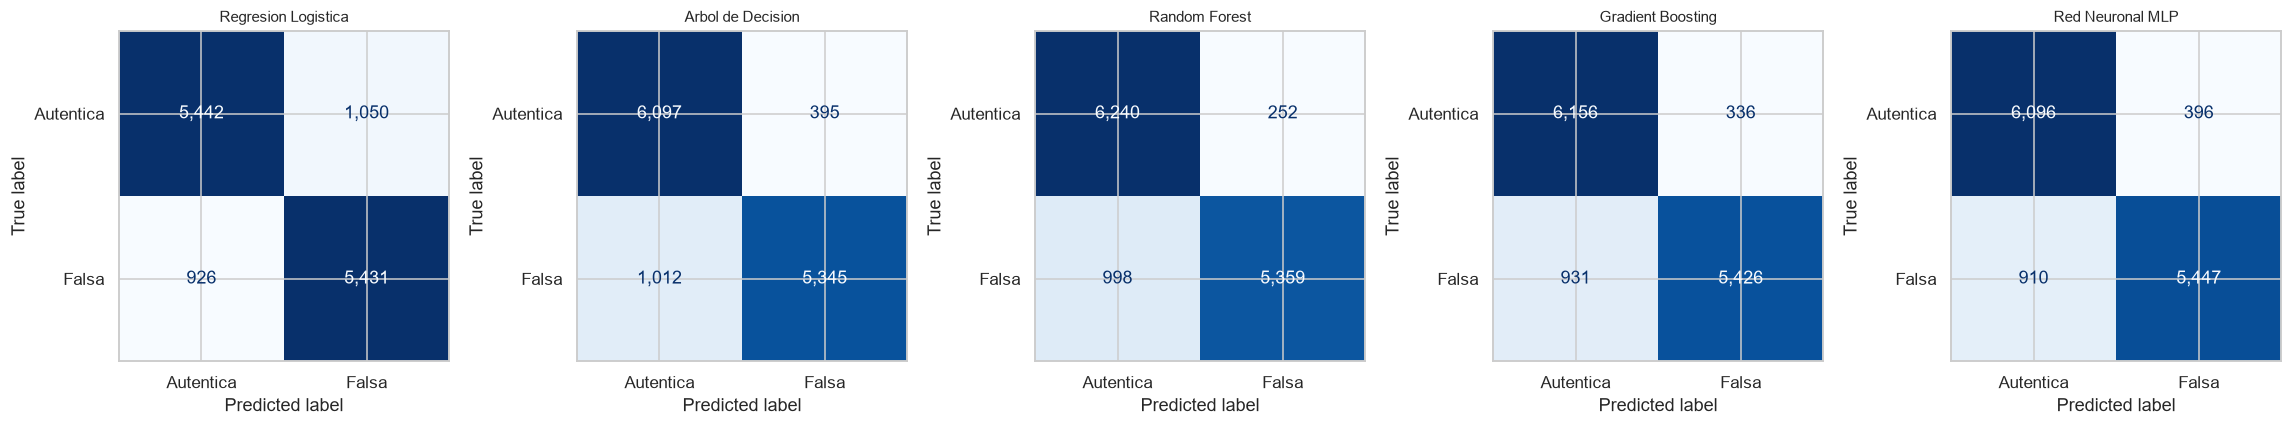

,falsos_negativos,falsos_positivos,errores_totales,pct_falsas_no_detectadas
modelo,,,,
Random Forest,998,252,1250,15.70
Gradient Boosting,931,336,1267,14.65
Red Neuronal MLP,910,396,1306,14.31
Arbol de Decision,1012,395,1407,15.92
Regresion Logistica,926,1050,1976,14.57


In [11]:
n = len(probabilidades)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
if n == 1:
    axes = [axes]

resumen_errores = []
for eje, (clave, prob) in zip(axes, probabilidades.items()):
    y_pred = (prob >= umbrales[clave]).astype(int)
    mc = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(mc, display_labels=['Autentica', 'Falsa']).plot(
        ax=eje, cmap='Blues', colorbar=False, values_format=',')
    eje.set_title(NOMBRES.get(clave, clave), fontsize=10)
    tn, fp, fn, tp = mc.ravel()
    resumen_errores.append({
        'modelo': NOMBRES.get(clave, clave),
        'falsos_negativos': int(fn),   # cuentas falsas aprobadas como autenticas
        'falsos_positivos': int(fp),   # cuentas autenticas rechazadas
        'errores_totales': int(fn + fp),
        'pct_falsas_no_detectadas': round(fn / (fn + tp) * 100, 2),
    })

plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/27_matrices_confusion.png', bbox_inches='tight'); plt.show()

display(pd.DataFrame(resumen_errores).set_index('modelo').sort_values('errores_totales'))

## 6. Análisis de errores: ¿dónde fallan y en qué se parecen?

Dos modelos pueden tener el mismo F1 y equivocarse en cuentas completamente distintas. Saber si los
errores se solapan dice algo que la tabla de métricas no muestra: si todos fallan en las mismas
cuentas, el límite está en los datos y no en el algoritmo.

In [12]:
aciertos = pd.DataFrame({
    NOMBRES.get(k, k): ((prob >= umbrales[k]).astype(int) == y_test)
    for k, prob in probabilidades.items()
})

n_modelos = aciertos.shape[1]
correctos_por_cuenta = aciertos.sum(axis=1)

reparto = pd.Series({
    f'{i} de {n_modelos} modelos aciertan': int((correctos_por_cuenta == i).sum())
    for i in range(n_modelos + 1)
})
reparto_pct = (reparto / len(y_test) * 100).round(2)
display(pd.DataFrame({'cuentas': reparto, 'porcentaje': reparto_pct}))

dificiles = correctos_por_cuenta == 0
print(f'\nCuentas que TODOS los modelos clasifican mal: {int(dificiles.sum()):,} ({dificiles.mean():.2%})')
print(f'Cuentas que TODOS clasifican bien: {int((correctos_por_cuenta == n_modelos).sum()):,} '
      f'({(correctos_por_cuenta == n_modelos).mean():.2%})')

,cuentas,porcentaje
0 de 5 modelos aciertan,583,4.54
1 de 5 modelos aciertan,372,2.90
2 de 5 modelos aciertan,296,2.30
3 de 5 modelos aciertan,360,2.80
4 de 5 modelos aciertan,1195,9.30
5 de 5 modelos aciertan,10043,78.16



Cuentas que TODOS los modelos clasifican mal: 583 (4.54%)
Cuentas que TODOS clasifican bien: 10,043 (78.16%)


In [13]:
# Perfil de las cuentas imposibles: en que se diferencian del resto
if dificiles.sum() > 0:
    perfil = pd.DataFrame({
        'cuentas_dificiles': X_test[dificiles.values].median(),
        'resto': X_test[~dificiles.values].median(),
    })
    perfil['veces'] = (perfil.cuentas_dificiles / (perfil.resto.abs() + 1e-9)).round(2)
    display(perfil.round(3))
    print(f'\nEtiqueta real de las cuentas dificiles: '
          f'{int(y_test[dificiles.values].sum())} falsas, '
          f'{int((1 - y_test[dificiles.values]).sum())} autenticas')

,cuentas_dificiles,resto,veces
pos,41.000,31.000,1.320000e+00
flw,438.000,347.000,1.260000e+00
flg,937.000,1000.000,9.400000e-01
bl,79.000,34.000,2.320000e+00
pic,1.000,1.000,1.000000e+00
lin,1.000,0.000,1.000000e+09
cl,84.000,46.000,1.830000e+00
cz,0.056,0.056,1.000000e+00
ni,0.111,0.077,1.440000e+00
erl,9.210,9.570,9.600000e-01



Etiqueta real de las cuentas dificiles: 499 falsas, 84 autenticas


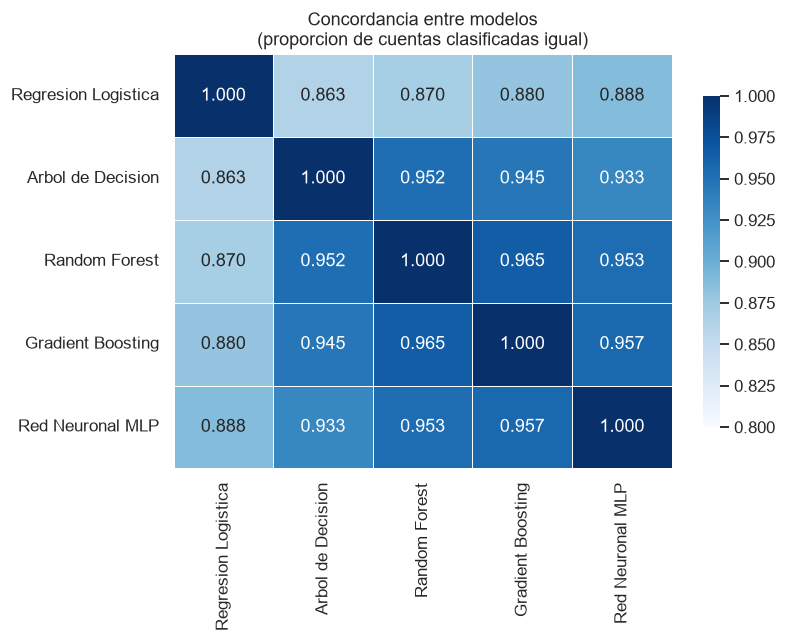

In [14]:
# Concordancia entre modelos: proporcion de cuentas en las que dos modelos deciden lo mismo
decisiones = pd.DataFrame({
    NOMBRES.get(k, k): (prob >= umbrales[k]).astype(int)
    for k, prob in probabilidades.items()
})
concordancia = pd.DataFrame(index=decisiones.columns, columns=decisiones.columns, dtype=float)
for a in decisiones.columns:
    for b in decisiones.columns:
        concordancia.loc[a, b] = (decisiones[a] == decisiones[b]).mean()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(concordancia.astype(float), annot=True, fmt='.3f', cmap='Blues',
            vmin=0.8, vmax=1.0, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Concordancia entre modelos\n(proporcion de cuentas clasificadas igual)')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/28_concordancia.png', bbox_inches='tight'); plt.show()

## 7. ¿La diferencia entre los dos mejores modelos es real?

Cuando dos modelos quedan separados por unas milésimas de F1, la pregunta correcta no es cuál tiene
el número más alto, sino si esa diferencia sobreviviría a otra muestra de cuentas.

La **prueba de McNemar** responde exactamente eso. Solo mira las cuentas donde los dos modelos
discrepan: aquellas donde el modelo A acierta y B falla, y viceversa. Si la diferencia fuera azar,
ambos conteos deberían ser parecidos. Un valor p bajo indica que un modelo es sistemáticamente mejor;
un valor p alto significa que, con la evidencia disponible, no se puede afirmar que uno supere al otro
—y en ese caso la elección debe apoyarse en otros criterios, como interpretabilidad o costo de
entrenamiento.

In [15]:
def mcnemar(aciertos_a, aciertos_b):
    """Prueba de McNemar exacta sobre los desacuerdos entre dos clasificadores."""
    solo_a = int((aciertos_a & ~aciertos_b).sum())   # acierta A, falla B
    solo_b = int((~aciertos_a & aciertos_b).sum())   # acierta B, falla A
    n = solo_a + solo_b
    p = binomtest(solo_a, n, 0.5).pvalue if n > 0 else 1.0
    return solo_a, solo_b, n, p

if len(tabla_opt) >= 2:
    m1, m2 = tabla_opt.index[0], tabla_opt.index[1]
    a1, a2 = aciertos[m1].values, aciertos[m2].values
    solo_1, solo_2, n_desacuerdos, p_valor = mcnemar(a1, a2)

    print(f'Comparacion: {m1}  vs  {m2}\n')
    print(f'Cuentas donde solo acierta {m1}: {solo_1:,}')
    print(f'Cuentas donde solo acierta {m2}: {solo_2:,}')
    print(f'Total de desacuerdos: {n_desacuerdos:,} de {len(y_test):,} cuentas')
    print(f'\nValor p (McNemar exacta): {p_valor:.6f}')
    if p_valor < 0.05:
        print(f'-> La diferencia es estadisticamente significativa (p < 0.05): '
              f'{m1 if solo_1 > solo_2 else m2} es sistematicamente mejor.')
    else:
        print('-> No hay evidencia suficiente para afirmar que un modelo supere al otro (p >= 0.05). '
              'La eleccion debe basarse en otros criterios.')

Comparacion: Random Forest  vs  Gradient Boosting

Cuentas donde solo acierta Random Forest: 234
Cuentas donde solo acierta Gradient Boosting: 217
Total de desacuerdos: 451 de 12,849 cuentas

Valor p (McNemar exacta): 0.451240
-> No hay evidencia suficiente para afirmar que un modelo supere al otro (p >= 0.05). La eleccion debe basarse en otros criterios.


In [16]:
# Todas las comparaciones por pares, para la tabla del informe
pares = []
nombres_modelos = list(aciertos.columns)
for i in range(len(nombres_modelos)):
    for j in range(i + 1, len(nombres_modelos)):
        a, b = nombres_modelos[i], nombres_modelos[j]
        s_a, s_b, n_d, p = mcnemar(aciertos[a].values, aciertos[b].values)
        pares.append({
            'modelo_A': a, 'modelo_B': b,
            'solo_acierta_A': s_a, 'solo_acierta_B': s_b,
            'desacuerdos': n_d, 'valor_p': round(p, 6),
            'significativa': 'si' if p < 0.05 else 'no',
        })
display(pd.DataFrame(pares).sort_values('valor_p'))

,modelo_A,modelo_B,solo_acierta_A,solo_acierta_B,desacuerdos,valor_p,significativa
0,Regresion Logistica,Arbol de Decision,597,1166,1763,0.000000,si
1,Regresion Logistica,Random Forest,471,1197,1668,0.000000,si
2,Regresion Logistica,Gradient Boosting,417,1126,1543,0.000000,si
3,Regresion Logistica,Red Neuronal MLP,385,1055,1440,0.000000,si
4,Arbol de Decision,Random Forest,231,388,619,0.000000,si
5,Arbol de Decision,Gradient Boosting,282,422,704,0.000000,si
6,Arbol de Decision,Red Neuronal MLP,378,479,857,0.000627,si
8,Random Forest,Red Neuronal MLP,330,274,604,0.025146,si
9,Gradient Boosting,Red Neuronal MLP,297,258,555,0.106658,no
7,Random Forest,Gradient Boosting,234,217,451,0.451240,no


## 8. ¿Coinciden los cinco algoritmos sobre qué delata una cuenta falsa?

Cada familia de modelos explica sus decisiones con un método distinto: la regresión con coeficientes,
los árboles con reducción de impureza, el boosting con SHAP, la red con permutación. Las magnitudes
no son comparables entre sí —están en unidades diferentes— pero **el orden sí lo es**.

Por eso la comparación se hace sobre rangos: la variable más influyente de cada modelo recibe el
puesto 1. Si cinco algoritmos con supuestos tan distintos coinciden en los primeros puestos, la
conclusión sobre qué señales delatan una cuenta falsa no depende del algoritmo elegido. Ese es el
argumento más sólido que puede ofrecer el proyecto, y es lo que sostiene el requisito de
interpretabilidad más allá de cada modelo por separado.

In [17]:
# Explicacion principal de cada modelo, tal como la dejo su notebook
FUENTE_EXPLICACION = {
    'regresion_logistica': ('importancia', 'Coeficientes (valor absoluto)'),
    'arbol_decision':      ('importancia', 'Reduccion de impureza'),
    'random_forest':       ('importancia_permutacion', 'Permutacion'),
    'gradient_boosting':   ('importancia_shap', 'SHAP'),
    'red_neuronal_mlp':    ('importancia_shap', 'SHAP'),
}

importancias = {}
metodos = {}
for clave, (campo, etiqueta) in FUENTE_EXPLICACION.items():
    info = metricas_reportadas.get(clave, {})
    valores = info.get(campo) or info.get('importancia') or info.get('importancia_permutacion')
    if valores:
        s = pd.Series(valores).reindex(VARIABLES).fillna(0).abs()
        importancias[NOMBRES[clave]] = s
        metodos[NOMBRES[clave]] = etiqueta

if importancias:
    matriz_imp = pd.DataFrame(importancias)
    rangos = matriz_imp.rank(ascending=False).astype(int)
    rangos['rango_promedio'] = rangos.mean(axis=1).round(2)
    rangos = rangos.sort_values('rango_promedio')

    print('Metodo de explicacion usado por cada modelo:')
    for m, e in metodos.items():
        print(f'  - {m}: {e}')
    print('\nPuesto de cada variable segun cada modelo (1 = mas influyente):')
    display(rangos)
else:
    print('No se encontraron importancias en los archivos JSON de resultados.')

Metodo de explicacion usado por cada modelo:
  - Regresion Logistica: Coeficientes (valor absoluto)
  - Arbol de Decision: Reduccion de impureza
  - Random Forest: Permutacion
  - Gradient Boosting: SHAP
  - Red Neuronal MLP: SHAP

Puesto de cada variable segun cada modelo (1 = mas influyente):


,Regresion Logistica,Arbol de Decision,Random Forest,Gradient Boosting,Red Neuronal MLP,rango_promedio
flg,1,2,1,3,3,2.0
lin,4,1,3,2,1,2.2
erc,5,5,2,1,2,3.0
erl,3,3,4,4,4,3.6
flw,2,4,5,5,5,4.2
bl,10,7,6,6,8,7.4
pos,14,8,7,9,7,9.0
pr,6,10,8,11,10,9.0
lt,12,6,10,7,12,9.4
cz,7,14,15,8,6,10.0


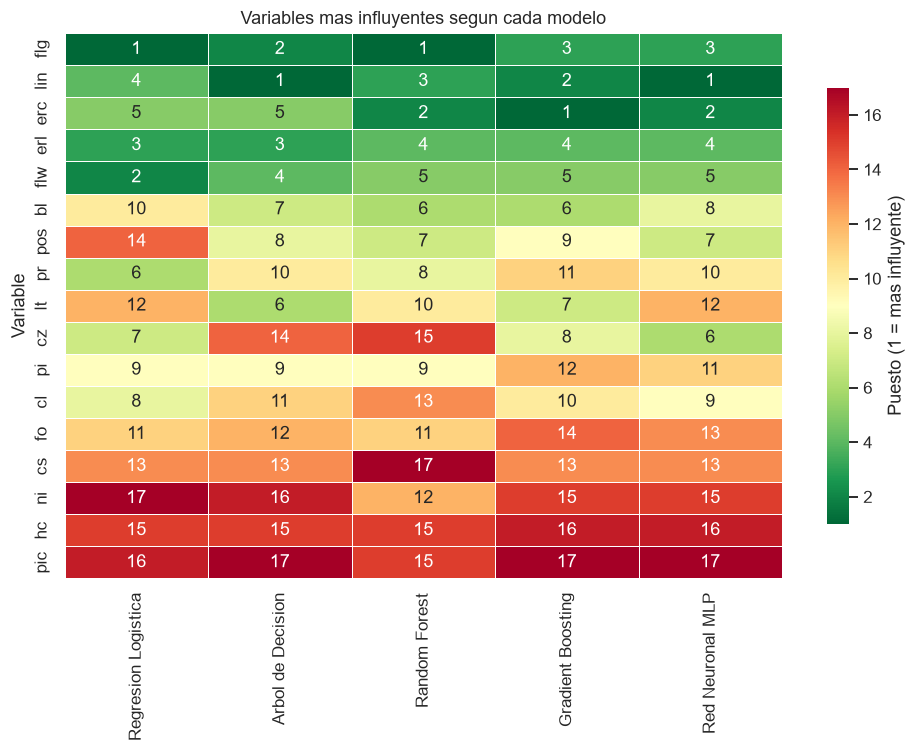

Variables presentes en el top 5 de TODOS los modelos: [np.str_('erc'), np.str_('erl'), np.str_('flg'), np.str_('flw'), np.str_('lin')]

En cuantos modelos aparece cada variable dentro del top 5:


,n_modelos
erc,5
flw,5
erl,5
lin,5
flg,5


In [18]:
if importancias:
    orden_var = rangos.index
    solo_rangos = rangos.drop(columns='rango_promedio').loc[orden_var]

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(solo_rangos, annot=True, fmt='d', cmap='RdYlGn_r',
                cbar_kws={'label': 'Puesto (1 = mas influyente)', 'shrink': 0.8},
                linewidths=0.5, ax=ax)
    ax.set_title('Variables mas influyentes segun cada modelo')
    ax.set_ylabel('Variable')
    plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/29_importancia_comparada.png', bbox_inches='tight'); plt.show()

    top5 = {m: set(solo_rangos[m].nsmallest(5).index) for m in solo_rangos.columns}
    consenso = set.intersection(*top5.values()) if top5 else set()
    print('Variables presentes en el top 5 de TODOS los modelos:', sorted(consenso) or 'ninguna')
    conteo = pd.Series([v for s in top5.values() for v in s]).value_counts()
    print('\nEn cuantos modelos aparece cada variable dentro del top 5:')
    display(conteo.to_frame('n_modelos'))

## 9. Costo de entrenamiento e interpretabilidad

El F1 no es el único criterio declarado en el proyecto. La Sección 5.2 de la Tarea #3 estableció que,
como la decisión final la toma una marca que necesita justificar en qué se basó para invertir, un
modelo que además de clasificar permita explicar qué señales motivaron cada decisión es preferible.
Esta tabla reúne los tres criterios para la elección final.

In [19]:
INTERPRETABILIDAD = {
    'Regresion Logistica': ('Directa', 'Coeficientes y odds ratios legibles sin herramientas externas'),
    'Arbol de Decision':   ('Directa', 'Reglas explicitas en unidades reales'),
    'Random Forest':       ('Indirecta', 'Requiere importancia por permutacion; SHAP es costoso'),
    'Gradient Boosting':   ('Indirecta', 'SHAP rapido y explicacion por cuenta individual'),
    'Red Neuronal MLP':    ('Indirecta', 'Requiere permutacion y SHAP; sin coeficientes legibles'),
}

resumen = tabla_opt[['f1_falsa', 'recall_falsa', 'auc_roc']].copy()
resumen['interpretabilidad'] = [INTERPRETABILIDAD.get(m, ('-', '-'))[0] for m in resumen.index]
resumen['como_se_explica'] = [INTERPRETABILIDAD.get(m, ('-', '-'))[1] for m in resumen.index]

# Hiperparametros finales reportados por cada notebook
hiper = {}
for clave, info in metricas_reportadas.items():
    if clave in NOMBRES and isinstance(info, dict):
        hiper[NOMBRES[clave]] = json.dumps(info.get('hiperparametros', {}), ensure_ascii=False)
resumen['hiperparametros_finales'] = [hiper.get(m, '-') for m in resumen.index]

display(resumen)

,f1_falsa,recall_falsa,auc_roc,interpretabilidad,como_se_explica,hiperparametros_finales
modelo,,,,,,
Random Forest,0.8956,0.8430,0.9619,Indirecta,Requiere importancia por permutacion; SHAP es ...,"{""max_features"": 0.5, ""min_samples_leaf"": 1, ""..."
Gradient Boosting,0.8955,0.8535,0.9624,Indirecta,SHAP rapido y explicacion por cuenta individual,"{""subsample"": 0.8, ""max_depth"": 3, ""learning_r..."
Red Neuronal MLP,0.8930,0.8569,0.9607,Indirecta,Requiere permutacion y SHAP; sin coeficientes ...,"{""dropout"": 0.3, ""optimizador"": ""Adam"", ""learn..."
Arbol de Decision,0.8837,0.8408,0.9462,Directa,Reglas explicitas en unidades reales,"{""criterion"": ""entropy"", ""max_depth"": 10, ""min..."
Regresion Logistica,0.8461,0.8543,0.9221,Directa,Coeficientes y odds ratios legibles sin herram...,"{""C"": 1.0, ""penalty"": ""l1""}"


### Selección del modelo final

La regla de decisión que conviene aplicar, en este orden:

1. **Descartar los modelos significativamente peores** según las pruebas de McNemar de la Sección 7.
2. **Entre los que quedan empatados estadísticamente**, elegir el más interpretable, porque el proyecto
   declaró la explicabilidad como restricción dura, no como una mejora deseable.
3. **Si aun así hay empate**, preferir el más barato de entrenar y mantener.

Redactar la conclusión con ese razonamiento explícito vale más que elegir el modelo con el número más
alto sin justificar por qué. Si el mejor F1 pertenece a un modelo que empata estadísticamente con otro
más interpretable, la elección defendible es el segundo, y hay que decirlo así.

## 10. Guardado de la comparación final

In [20]:
tabla_opt.to_csv(f'{RUTA_FIGS}/tabla_comparativa_final.csv')
if importancias:
    rangos.to_csv(f'{RUTA_FIGS}/ranking_importancia_variables.csv')

comparacion_final = {
    'n_modelos_comparados': len(probabilidades),
    'n_registros_prueba': int(len(y_test)),
    'metricas_umbral_05': tabla_05.round(4).reset_index().to_dict(orient='records'),
    'metricas_umbral_optimo': tabla_opt.round(4).reset_index().to_dict(orient='records'),
    'umbrales': {NOMBRES.get(k, k): round(v, 4) for k, v in umbrales.items()},
    'mejor_por_f1': tabla_opt.index[0],
    'errores': resumen_errores,
    'mcnemar_por_pares': pares,
    'cuentas_que_todos_fallan': int(dificiles.sum()),
    'variables_consenso_top5': sorted(consenso) if importancias else [],
}
with open(f'{RUTA_RES}/comparacion_final.json', 'w', encoding='utf-8') as fh:
    json.dump(comparacion_final, fh, indent=2, ensure_ascii=False)

print('Guardado:')
print(f'  - {RUTA_FIGS}/tabla_comparativa_final.csv')
print(f'  - {RUTA_RES}/comparacion_final.json')
print(f'  - Figuras 24 a 29 en {RUTA_FIGS}')

Guardado:
  - C:/Users/JDC/Drive/Proyecto_IA_Grupo4/figuras/tabla_comparativa_final.csv
  - C:/Users/JDC/Drive/Proyecto_IA_Grupo4/resultados/comparacion_final.json
  - Figuras 24 a 29 en C:/Users/JDC/Drive/Proyecto_IA_Grupo4/figuras


---
## Checklist de entrega — Notebook 04

- [ ] Verificación de partición pasada sin errores (los tres notebooks usaron el mismo split).
- [ ] Tabla comparativa de los cinco modelos, con umbral 0.5 y umbral optimizado.
- [ ] Figura con las curvas ROC y precisión-recall superpuestas.
- [ ] Matrices de confusión de los cinco modelos y conteo de falsos negativos.
- [ ] Resultado de las pruebas de McNemar entre pares.
- [ ] Mapa de calor de variables influyentes y lista de variables de consenso.
- [ ] Modelo final elegido, con la justificación de los tres criterios redactada.
- [ ] Figuras exportadas a `figuras/` (numeradas de la 24 a la 29) y `comparacion_final.json`
      en `resultados/`.

### Material que este notebook aporta al informe

| Sección del informe | Qué usar de aquí |
|---|---|
| Resultados | Tabla comparativa y figura de métricas (Sección 3) |
| Resultados | Curvas ROC y precisión-recall (Sección 4) |
| Discusión | Análisis de errores y cuentas que todos fallan (Sección 6) |
| Discusión | Pruebas de McNemar (Sección 7) |
| Interpretabilidad | Mapa de calor de variables influyentes (Sección 8) |
| Conclusiones | Tabla de criterios y modelo elegido (Sección 9) |